In [143]:
src="giss"
rec="GISTEMP v4 LOTI"
tmp=read.csv("https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv",skip=1,na.strings="***")
temp0=c(t(tmp[,2:13]))
bstryr=1850
bendyr=1900
stmon=1

# adjust data from the outset so we're comparing like with like throughout
if (src == "giss" & bstryr==1850) {tmp[,2:13]  = tmp[,2:13] -0.02} # fix to get 'pre-industrial' based on other time-series that go back further

stryr=tmp[1,1]  # start year of index 
endyr=tmp[dim(tmp)[1],1] # current year
yrs=stryr:endyr
curr=tail(which(!is.na(tail(temp0,12))),1) # last available month

# vector with dates
temp=cbind(stryr+((1:length(temp0)-0.5)/12),temp0)

ann=NA*(1:(endyr-stryr))
ytd=NA*(1:(endyr-stryr+1))

# rebaseline 
base=mean(temp[temp[,1] > bstryr & temp[,1] < bendyr+1,2])
temp[,2]=temp[,2]-base
# if (src == "giss" & bstryr==1850) {temp[,2] = temp[,2]-0.02} # fix to get 'pre-industrial' based on other time-series that go back further

for (i in 1:(endyr-stryr+1)) {ytd[i]=mean(temp[(12*(i-1)+stmon):(12*(i-1)+curr+stmon-1),2])}
for (i in 1:(endyr-stryr)) {ann[i]=mean(temp[(12*(i-1)+stmon):(12*i+stmon-1),2])}

ytd1=ytd[1:(endyr-stryr)]

# linear regression btw ann and ytd
fred=lm(ann ~ ytd1)
pred=predict(fred,newdata=data.frame(ytd1=ytd[endyr-stryr+1]),se.fit=TRUE,interval="prediction")

In [144]:
# use infilling method to compare
tmp_filled <- tmp
tmp_filled[,4:13] <- rowMeans(tmp_filled[,2:3])

df_persistence <- data.frame("year" = tmp_filled$Year, "gmst_ps" = rowMeans(tmp_filled[,2:13]))

In [145]:
# makes plotting easier
df_ann = data.frame(year = 1880:2025, gmst_ann = ann)
df_lm = data.frame(year = 1880:2025, gmst_lm = predict(fred))
df_all <- merge(merge(df_ann, df_lm), df_persistence)

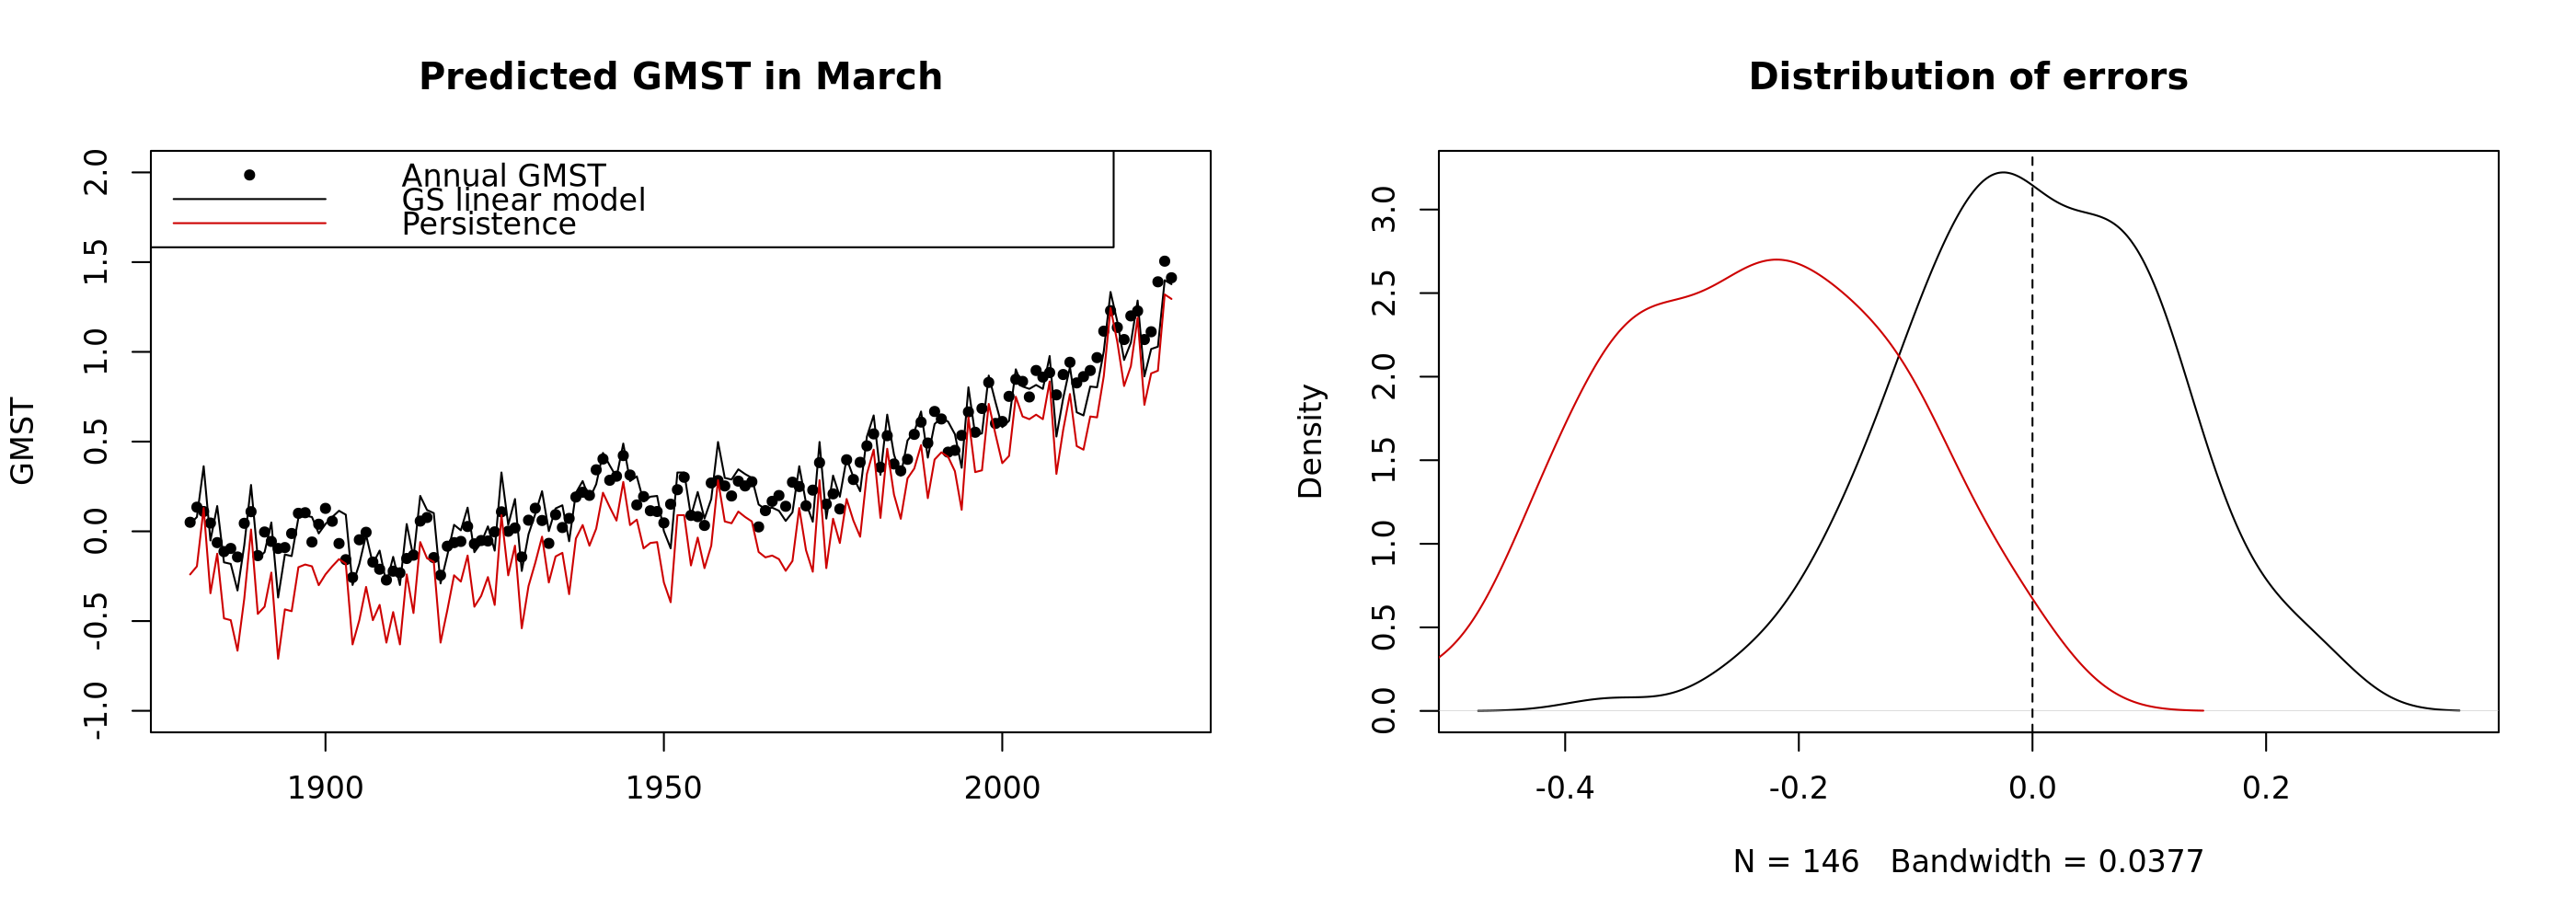

In [146]:
rwwa::prep_window(c(1,2), w = 7, h = 5)
plot(df_all$year, ann, xlab = "", ylab = "GMST", ylim = c(-1,2), main = "Predicted GMST in March")
lines(df_all$year, df_all$gmst_lm)
lines(df_all$year, df_all$gmst_ps, col = "red3")

legend("topleft", c("Annual GMST", "GS linear model", "Persistence"), pch = c(20,NA, NA), lty = c(NA, 1, 1), col = c("black", "black", "red3"))

plot(density(df_all$gmst_lm - df_all$gmst_ann), main = "Distribution of errors")
lines(density(df_all$gmst_ps - df_all$gmst_ann), col = "red3")
abline(v = 0, col = "black", lty = 2)